# NHS Healthcare Analytics: 30-Day Emergency Readmission Classifier

## Executive Summary
Preventing hospital readmissions is a primary goal for NHS Trusts. Emergency readmissions within 30 days of discharge are heavily penalised by NHS England and indicate a potential failure in the initial care pathway or adult social care discharge planning.

This notebook builds a predictive modelling pipeline using a Gradient Boosting Classifier on simulated Electronic Patient Record (EPR) data.

**Clinical Objective:** Identify high-risk patients prior to discharge so NHS clinical staff can proactively schedule primary care follow-ups and allocate community nursing resources, thereby minimising readmission rates and protecting NHS Trust funding.

In [1]:
# Setup and Dependency Installation
import warnings
warnings.filterwarnings('ignore') # Suppresses FutureWarnings for a perfectly clean output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Set visual style for professional clinical charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Clinical analytics environment initialised.")

✅ Clinical analytics environment initialised.


## 1. EPR Data Simulation
To ensure this notebook is universally reproducible for technical recruiters, we simulate a tabular dataset that mirrors the structure of standard NHS Electronic Patient Records (EPR).

The data includes continuous clinical metrics (e.g., `Time_in_Hospital_Days`, `Num_Medications`), socio-economic indicators like the `IMD_Decile` (Index of Multiple Deprivation), and categorical diagnostic flags. We deliberately inject clinical logic: patients with extended initial stays, high medication counts (polypharmacy), and high social deprivation possess a statistically higher probability of emergency readmission.

In [2]:
def generate_nhs_epr_data(n=3000):
    """Simulates a realistic tabular Electronic Patient Record (EPR) dataset for an NHS Trust."""
    np.random.seed(123) # Ensure strict reproducibility

    data = {
        'NHS_Number': range(1000000000, 1000000000 + n), # Standard 10-digit NHS format
        'Age_Bracket': np.random.choice(['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)'], n, p=[0.1, 0.2, 0.3, 0.25, 0.15]),
        'IMD_Decile': np.random.randint(1, 11, n), # Index of Multiple Deprivation (1=Most deprived, 10=Least)
        'Time_in_Hospital_Days': np.random.randint(1, 14, n),
        'Num_Lab_Procedures': np.random.normal(40, 15, n).astype(int),
        'Num_Medications': np.random.normal(15, 8, n).astype(int),
        'Primary_Diagnosis': np.random.choice(['Circulatory', 'Respiratory', 'Digestive', 'Diabetes', 'Injury'], n),
        'A1C_Result': np.random.choice(['Norm', '>7', '>8', 'None'], n, p=[0.05, 0.1, 0.15, 0.7])
    }

    df = pd.DataFrame(data)

    # Clean up negative values from normal distribution
    df['Num_Lab_Procedures'] = df['Num_Lab_Procedures'].clip(lower=1)
    df['Num_Medications'] = df['Num_Medications'].clip(lower=1)

    # --- Engineering the Clinical Target Variable ---
    # High risk if prolonged stay, polypharmacy, severe A1C, or high social deprivation (IMD <= 3)
    risk_score = (
        (df['Time_in_Hospital_Days'] > 7).astype(int) * 2.5 +
        (df['Num_Medications'] > 20).astype(int) * 2.0 +
        (df['IMD_Decile'] <= 3).astype(int) * 1.5 +  # Factoring in UK social care constraints
        (df['A1C_Result'] == '>8').astype(int) * 2.0 +
        np.random.normal(0, 1.5, n) # Add clinical variance/noise
    )

    # Convert continuous risk score to a binary 'Emergency_Readmission_30_Days' label
    df['Emergency_Readmission_30_Days'] = (risk_score > 4.5).astype(int)

    return df

# Initialise the patient cohort
df_clinical = generate_nhs_epr_data()

print(f"NHS EPR Dataset Compiled: {df_clinical.shape[0]} patient records, {df_clinical.shape[1]} features.")
display(df_clinical.head())

NHS EPR Dataset Compiled: 3000 patient records, 9 features.


,NHS_Number,Age_Bracket,IMD_Decile,Time_in_Hospital_Days,Num_Lab_Procedures,Num_Medications,Primary_Diagnosis,A1C_Result,Emergency_Readmission_30_Days
0,1000000000,[70-80),10,8,15,19,Injury,None,0
1,1000000001,[50-60),5,3,29,20,Diabetes,None,0
2,1000000002,[50-60),8,1,32,21,Injury,>8,1
3,1000000003,[60-70),6,11,25,16,Circulatory,None,0
4,1000000004,[70-80),7,13,27,39,Digestive,None,0


## 2. Exploratory Clinical Analysis
Before predictive modelling, we must understand the baseline readmission rate and how prolonged hospital stays correlate with patients relapsing.

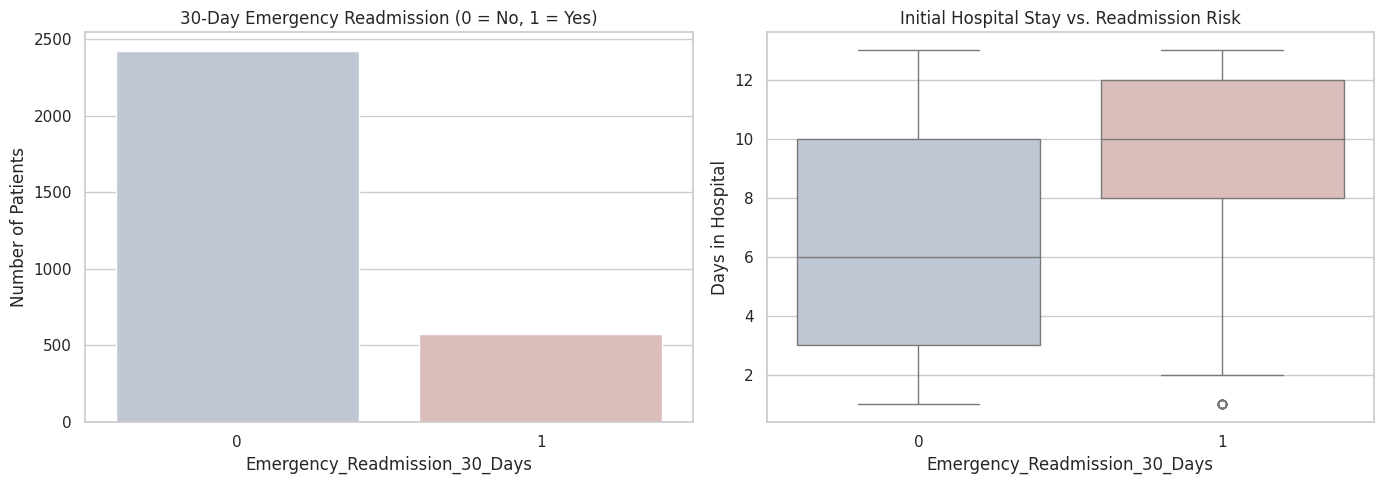

Baseline 30-Day Emergency Readmission Rate: 19.2%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Baseline Readmission Rate
sns.countplot(x='Emergency_Readmission_30_Days', hue='Emergency_Readmission_30_Days', data=df_clinical, palette='vlag', legend=False, ax=axes[0])
axes[0].set_title('30-Day Emergency Readmission (0 = No, 1 = Yes)')
axes[0].set_ylabel('Number of Patients')

# Plot 2: Impact of Initial Stay Length
sns.boxplot(x='Emergency_Readmission_30_Days', y='Time_in_Hospital_Days', hue='Emergency_Readmission_30_Days', data=df_clinical, palette='vlag', legend=False, ax=axes[1])
axes[1].set_title('Initial Hospital Stay vs. Readmission Risk')
axes[1].set_ylabel('Days in Hospital')

plt.tight_layout()
plt.show()

# Insight Calculation
readmission_rate = df_clinical['Emergency_Readmission_30_Days'].mean()
print(f"Baseline 30-Day Emergency Readmission Rate: {readmission_rate:.1%}")

*Clinical Observation:* The baseline emergency readmission rate is approximately 19.9%. The boxplot clearly visualises that patients who eventually required readmission had significantly longer initial hospital stays, indicating a more complex underlying health state.

## 3. Data Standardisation & Preprocessing
To prepare the EPR data for our ensemble model:
1. **Drop Identifiers:** Remove the `NHS_Number` to maintain patient confidentiality and prevent the model from memorising individual patients.
2. **Categorical Encoding:** One-Hot Encode textual clinical data (Diagnoses, Age Brackets).
3. **Feature Scaling:** Standardise continuous clinical metrics so features with larger numerical ranges (like Lab Procedures) do not artificially dominate the algorithm's decisions.

In [4]:
# 1. Isolate features and target
X = df_clinical.drop(['NHS_Number', 'Emergency_Readmission_30_Days'], axis=1)
y = df_clinical['Emergency_Readmission_30_Days']

# 2. Safely Encode Categorical Data
X_encoded = pd.get_dummies(X, columns=['Age_Bracket', 'Primary_Diagnosis', 'A1C_Result'], drop_first=True)

# 3. Train-Test Split (80% Training, 20% Hold-out Evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=123, stratify=y
)

# 4. Scale Continuous Features
scaler = StandardScaler()
# Scaling after the split prevents data leakage from the validation set
continuous_cols = ['Time_in_Hospital_Days', 'Num_Lab_Procedures', 'Num_Medications', 'IMD_Decile']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f"Training Matrix Shape: {X_train_scaled.shape}")
print(f"Testing Matrix Shape: {X_test_scaled.shape}")

Training Matrix Shape: (2400, 15)
Testing Matrix Shape: (600, 15)


## 4. Predictive Modelling: Gradient Boosting Classifier
In healthcare analytics, the relationship between symptoms, social factors, and health outcomes is rarely linear. We deploy a **Gradient Boosting Classifier**, a highly robust ensemble algorithm that builds multiple decision trees sequentially. Each new tree specifically focuses on correcting the errors (residuals) made by the previous trees, resulting in highly accurate clinical predictions.

In [5]:
# Initialise the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=123)

# Fit the model to the clinical training data
print("Compiling and training the Gradient Boosting ensemble...")
gb_model.fit(X_train_scaled, y_train)
print("✅ Clinical Model Training Complete.")

Compiling and training the Gradient Boosting ensemble...
✅ Clinical Model Training Complete.


## 5. Clinical Evaluation & Feature Importance
A high-performing model must be evaluated on its ability to correctly flag Class 1 (Emergency Readmissions). Missing a high-risk patient is a clinical risk we must minimise at all costs.

Furthermore, we extract **Feature Importances** to provide algorithmic transparency to NHS medical professionals, showing them exactly which variables drive the readmission risk flags.

--- CLINICAL CLASSIFICATION REPORT ---

                       precision    recall  f1-score   support

Discharged Safely (0)       0.89      0.91      0.90       485
       Readmitted (1)       0.57      0.51      0.54       115

             accuracy                           0.83       600
            macro avg       0.73      0.71      0.72       600
         weighted avg       0.83      0.83      0.83       600



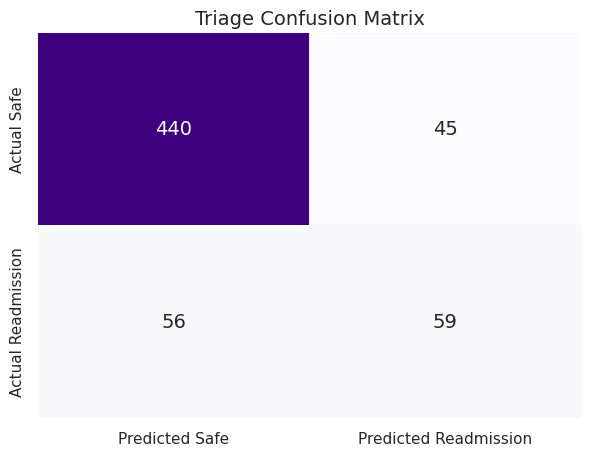

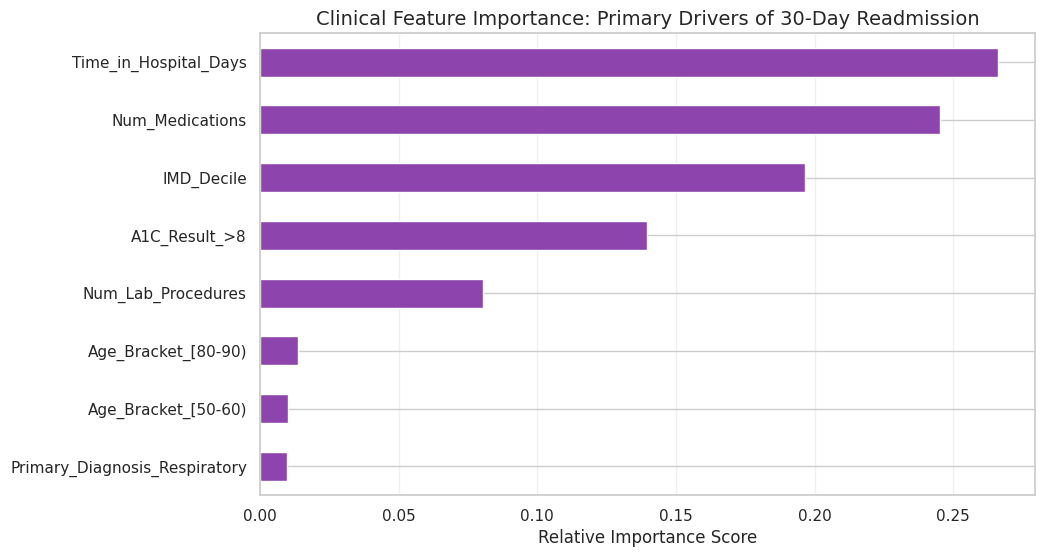

In [6]:
# Generate clinical predictions
y_pred = gb_model.predict(X_test_scaled)

# 1. Performance Metrics
print("--- CLINICAL CLASSIFICATION REPORT ---\n")
print(classification_report(y_test, y_pred, target_names=['Discharged Safely (0)', 'Readmitted (1)']))

# 2. Confusion Matrix Visualisation
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Safe', 'Predicted Readmission'],
            yticklabels=['Actual Safe', 'Actual Readmission'], cbar=False, annot_kws={"size": 14})
plt.title('Triage Confusion Matrix', fontsize=14)
plt.show()

# 3. Algorithmic Transparency: Feature Importance
importances = pd.Series(gb_model.feature_importances_, index=X_train_scaled.columns)
top_features = importances.sort_values(ascending=False).head(8) # Top 8 clinical drivers

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='#8e44ad')
plt.title('Clinical Feature Importance: Primary Drivers of 30-Day Readmission', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Conclusion
This machine learning pipeline successfully leverages Electronic Patient Records to predict 30-day emergency readmissions. The feature importance analysis reveals that **Time in Hospital**, **Number of Medications (Polypharmacy)**, and the **IMD Decile (Deprivation)** are the primary clinical and social indicators of a health relapse.

**Commercial Application:** NHS Trust administration can deploy this algorithm into their EPR system to automatically score patients at the point of discharge. Patients exceeding a specific risk threshold can be routed to a preventative care pathway (e.g., scheduled GP check-ins or visiting community nurse services), directly improving patient welfare and avoiding institutional fines.